# Evaluation and Comparison of CBIR Algorithms

This notebook compares four CBIR methods:
- Color Histogram
- GLCM Texture
- Hu Moments
- ORB

Evaluation is based on:
- Precision@5
- Precision@10

The goal is to identify which method performs better
for retrieving visually similar images from the dataset.

In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
DATASET_PATH = "processed_dataset"

categories = sorted(os.listdir(DATASET_PATH))
print("Categories:", categories)
print("Total categories:", len(categories))

Categories: ['ambulance', 'bicycle', 'bus', 'car', 'fire_truck', 'motorcycle', 'tractor', 'truck', 'van']
Total categories: 9


## Feature Extraction Functions

This section defines the feature extraction methods for the four CBIR algorithms.

### Color Histogram

In [3]:
def extract_color_histogram(image_path, bins=(8, 8, 8)):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    hist = cv2.calcHist([image], [0, 1, 2], None, bins,
                        [0, 256, 0, 256, 0, 256])

    hist = cv2.normalize(hist, hist).flatten()
    return hist

### GLCM

In [4]:
def extract_glcm_features(image_path, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    glcm = graycomatrix(
        image,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast').flatten()
    correlation = graycoprops(glcm, 'correlation').flatten()
    energy = graycoprops(glcm, 'energy').flatten()
    homogeneity = graycoprops(glcm, 'homogeneity').flatten()

    feature_vector = np.hstack([contrast, correlation, energy, homogeneity])
    return feature_vector

### Hu Moments

In [5]:
def extract_hu_moments(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    moments = cv2.moments(thresh)
    hu = cv2.HuMoments(moments).flatten()

    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return hu

### ORB

In [6]:
orb = cv2.ORB_create(nfeatures=1000)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

def extract_orb_descriptors(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    keypoints, descriptors = orb.detectAndCompute(image, None)
    return descriptors

def compute_orb_similarity(query_descriptors, train_descriptors):
    if query_descriptors is None or train_descriptors is None:
        return 0

    matches = bf.match(query_descriptors, train_descriptors)

    if len(matches) == 0:
        return 0

    matches = sorted(matches, key=lambda x: x.distance)
    good_matches = [m for m in matches if m.distance < 50]

    return len(good_matches)

## Build Databases for All Algorithms

This section extracts features from all images and stores them for evaluation.

In [7]:
all_image_paths = []
all_image_labels = []

for category in categories:
    category_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        all_image_paths.append(img_path)
        all_image_labels.append(category)

print("Total images:", len(all_image_paths))

Total images: 1800


### Build Color Histogram Database

In [8]:
color_features = []

for img_path in all_image_paths:
    feature = extract_color_histogram(img_path)
    color_features.append(feature)

color_features = np.array(color_features)
print("Color feature shape:", color_features.shape)

Color feature shape: (1800, 512)


### Build GLCM Database

In [9]:
glcm_features = []

for img_path in all_image_paths:
    feature = extract_glcm_features(img_path)
    glcm_features.append(feature)

glcm_features = np.array(glcm_features)
print("GLCM feature shape:", glcm_features.shape)

GLCM feature shape: (1800, 16)


### Build Hu Moments Database

In [10]:
hu_features = []

for img_path in all_image_paths:
    feature = extract_hu_moments(img_path)
    hu_features.append(feature)

hu_features = np.array(hu_features)
print("Hu feature shape:", hu_features.shape)

Hu feature shape: (1800, 7)


### Build ORB Database

In [11]:
orb_descriptors_db = []

for img_path in all_image_paths:
    desc = extract_orb_descriptors(img_path)
    orb_descriptors_db.append(desc)

print("ORB descriptor database built.")

ORB descriptor database built.


## Retrieval Functions

### Retrieval for Color, GLCM, Hu

In [12]:
def retrieve_by_similarity(query_image_path, feature_type="color", top_k=10):
    if feature_type == "color":
        query_feature = extract_color_histogram(query_image_path)
        database = color_features
    elif feature_type == "glcm":
        query_feature = extract_glcm_features(query_image_path)
        database = glcm_features
    elif feature_type == "hu":
        query_feature = extract_hu_moments(query_image_path)
        database = hu_features
    else:
        return []

    if query_feature is None:
        return []

    similarities = cosine_similarity([query_feature], database)[0]
    sorted_indices = np.argsort(similarities)[::-1]

    results = []
    for idx in sorted_indices:
        if all_image_paths[idx] == query_image_path:
            continue

        results.append({
            "image_path": all_image_paths[idx],
            "label": all_image_labels[idx],
            "score": similarities[idx]
        })

        if len(results) == top_k:
            break

    return results

### Retrieval for ORB

In [13]:
def retrieve_by_orb(query_image_path, top_k=10):
    query_desc = extract_orb_descriptors(query_image_path)

    if query_desc is None:
        return []

    results = []

    for i in range(len(all_image_paths)):
        if all_image_paths[i] == query_image_path:
            continue

        score = compute_orb_similarity(query_desc, orb_descriptors_db[i])

        results.append({
            "image_path": all_image_paths[i],
            "label": all_image_labels[i],
            "score": score
        })

    results = sorted(results, key=lambda x: x["score"], reverse=True)
    return results[:top_k]

## Evaluation Functions

### Precision@K

In [14]:
def precision_at_k(query_image_path, results, k=5):
    query_label = os.path.basename(os.path.dirname(query_image_path))
    correct = sum(1 for r in results[:k] if r["label"] == query_label)
    return correct / k

### Random Query Selection

In [15]:
def get_random_query_images(num_per_category=5):
    query_images = []

    for category in categories:
        category_path = os.path.join(DATASET_PATH, category)
        images = os.listdir(category_path)

        selected = random.sample(images, num_per_category)

        for img_name in selected:
            query_images.append(os.path.join(category_path, img_name))

    return query_images

## Run Evaluation

This section tests all four algorithms on multiple query images.

In [16]:
# Select Query Set
random.seed(42)  # for reproducible results

query_images = get_random_query_images(num_per_category=10)

print("Total query images selected:", len(query_images))
print("Example query:", query_images[3])

Total query images selected: 90
Example query: processed_dataset\ambulance\Y4NCD542HC5G.jpg


In [17]:
evaluation_results = []

for query_image in query_images:
    # Color Histogram
    color_results = retrieve_by_similarity(query_image, feature_type="color", top_k=10)
    color_p5 = precision_at_k(query_image, color_results, k=5)
    color_p10 = precision_at_k(query_image, color_results, k=10)

    # GLCM
    glcm_results = retrieve_by_similarity(query_image, feature_type="glcm", top_k=10)
    glcm_p5 = precision_at_k(query_image, glcm_results, k=5)
    glcm_p10 = precision_at_k(query_image, glcm_results, k=10)

    # Hu Moments
    hu_results = retrieve_by_similarity(query_image, feature_type="hu", top_k=10)
    hu_p5 = precision_at_k(query_image, hu_results, k=5)
    hu_p10 = precision_at_k(query_image, hu_results, k=10)

    # ORB
    orb_results = retrieve_by_orb(query_image, top_k=10)
    orb_p5 = precision_at_k(query_image, orb_results, k=5)
    orb_p10 = precision_at_k(query_image, orb_results, k=10)

    evaluation_results.append({
        "query_image": query_image,
        "category": os.path.basename(os.path.dirname(query_image)),
        "color_p5": color_p5,
        "color_p10": color_p10,
        "glcm_p5": glcm_p5,
        "glcm_p10": glcm_p10,
        "hu_p5": hu_p5,
        "hu_p10": hu_p10,
        "orb_p5": orb_p5,
        "orb_p10": orb_p10
    })

print("Evaluation completed.")

Evaluation completed.


In [18]:
df_results = pd.DataFrame(evaluation_results)
df_results.head()

,query_image,category,color_p5,color_p10,glcm_p5,glcm_p10,hu_p5,hu_p10,orb_p5,orb_p10
0,processed_dataset\ambulance\SGUVZELAI9R4.jpg,ambulance,0.0,0.0,0.2,0.3,0.2,0.1,0.4,0.4
1,processed_dataset\ambulance\4FYUTH6N3G0V.jpg,ambulance,0.4,0.2,0.4,0.3,0.2,0.1,0.0,0.2
2,processed_dataset\ambulance\1PRZBSP7WXZB.jpg,ambulance,0.4,0.4,0.4,0.2,0.2,0.2,0.4,0.2
3,processed_dataset\ambulance\Y4NCD542HC5G.jpg,ambulance,0.0,0.0,0.2,0.2,0.2,0.3,0.2,0.1
4,processed_dataset\ambulance\A50JSL325YLH.jpg,ambulance,0.2,0.1,0.2,0.2,0.0,0.1,0.0,0.0


In [19]:
df_results = pd.DataFrame(evaluation_results)
df_results.tail()

,query_image,category,color_p5,color_p10,glcm_p5,glcm_p10,hu_p5,hu_p10,orb_p5,orb_p10
85,processed_dataset\van\GS2CHDKAR5UO.jpg,van,0.4,0.3,0.0,0.0,0.4,0.2,0.8,0.6
86,processed_dataset\van\AKY900P15R94.jpg,van,0.2,0.1,0.0,0.0,0.0,0.1,0.2,0.2
87,processed_dataset\van\UDA4J4D9KUFU.jpg,van,0.0,0.0,0.2,0.1,0.0,0.3,0.2,0.3
88,processed_dataset\van\D4J5GKUGQMXI.jpg,van,0.6,0.5,0.0,0.0,0.0,0.1,1.0,1.0
89,processed_dataset\van\VQNZVFYEJRL8.jpg,van,0.2,0.2,0.2,0.1,0.2,0.2,0.4,0.4


## Average Performance of Each Algorithm

In [20]:
summary = pd.DataFrame({
    "Algorithm": ["Color Histogram", "GLCM", "Hu Moments", "ORB"],
    "Average Precision@5": [
        df_results["color_p5"].mean(),
        df_results["glcm_p5"].mean(),
        df_results["hu_p5"].mean(),
        df_results["orb_p5"].mean()
    ],
    "Average Precision@10": [
        df_results["color_p10"].mean(),
        df_results["glcm_p10"].mean(),
        df_results["hu_p10"].mean(),
        df_results["orb_p10"].mean()
    ]
})

summary

,Algorithm,Average Precision@5,Average Precision@10
0,Color Histogram,0.260000,0.220000
1,GLCM,0.233333,0.217778
2,Hu Moments,0.155556,0.146667
3,ORB,0.266667,0.245556


## Bar Chart Comparison

### Plot Precision@5

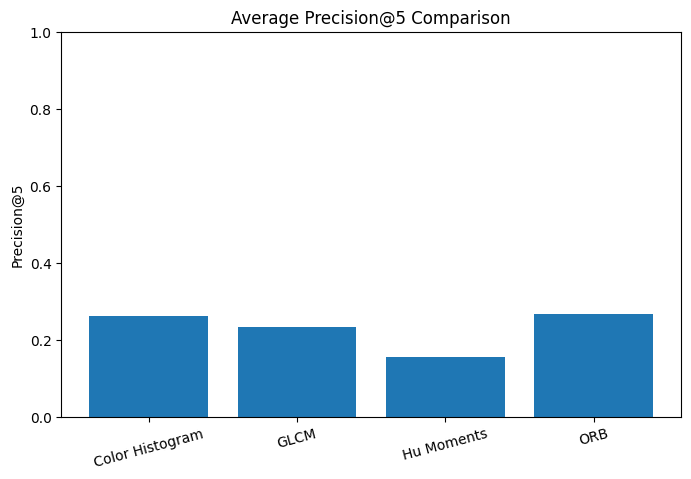

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(summary["Algorithm"], summary["Average Precision@5"])
plt.title("Average Precision@5 Comparison")
plt.ylabel("Precision@5")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

### Plot Precision@10

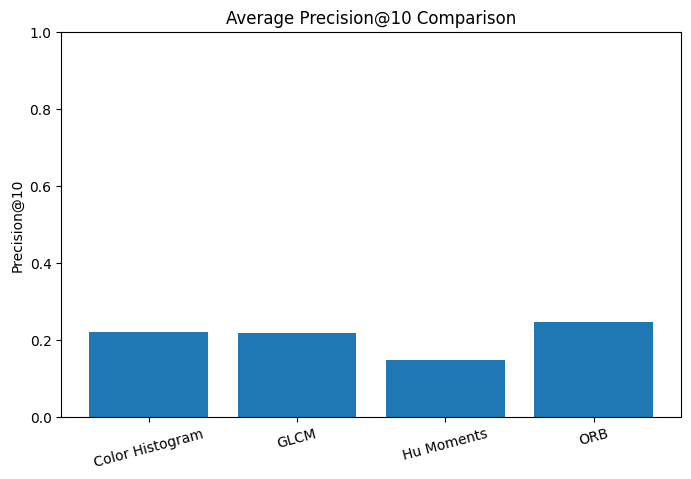

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(summary["Algorithm"], summary["Average Precision@10"])
plt.title("Average Precision@10 Comparison")
plt.ylabel("Precision@10")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

## Performance by Category

In [23]:
category_summary = df_results.groupby("category")[[
    "color_p5", "glcm_p5", "hu_p5", "orb_p5"
]].mean()

category_summary

,color_p5,glcm_p5,hu_p5,orb_p5
category,,,,
ambulance,0.18,0.32,0.12,0.20
bicycle,0.46,0.40,0.18,0.64
bus,0.18,0.08,0.28,0.16
car,0.30,0.44,0.08,0.42
fire_truck,0.20,0.24,0.06,0.12
motorcycle,0.38,0.28,0.22,0.06
tractor,0.14,0.20,0.18,0.18
truck,0.16,0.06,0.14,0.16
van,0.34,0.08,0.14,0.46


In [24]:
category_summary = df_results.groupby("category")[[
    "color_p10", "glcm_p10", "hu_p10", "orb_p10"
]].mean()

category_summary

,color_p10,glcm_p10,hu_p10,orb_p10
category,,,,
ambulance,0.13,0.26,0.13,0.17
bicycle,0.41,0.33,0.20,0.63
bus,0.13,0.10,0.19,0.15
car,0.29,0.41,0.09,0.30
fire_truck,0.19,0.22,0.12,0.10
motorcycle,0.30,0.26,0.22,0.08
tractor,0.11,0.20,0.12,0.12
truck,0.12,0.11,0.10,0.19
van,0.30,0.07,0.15,0.47


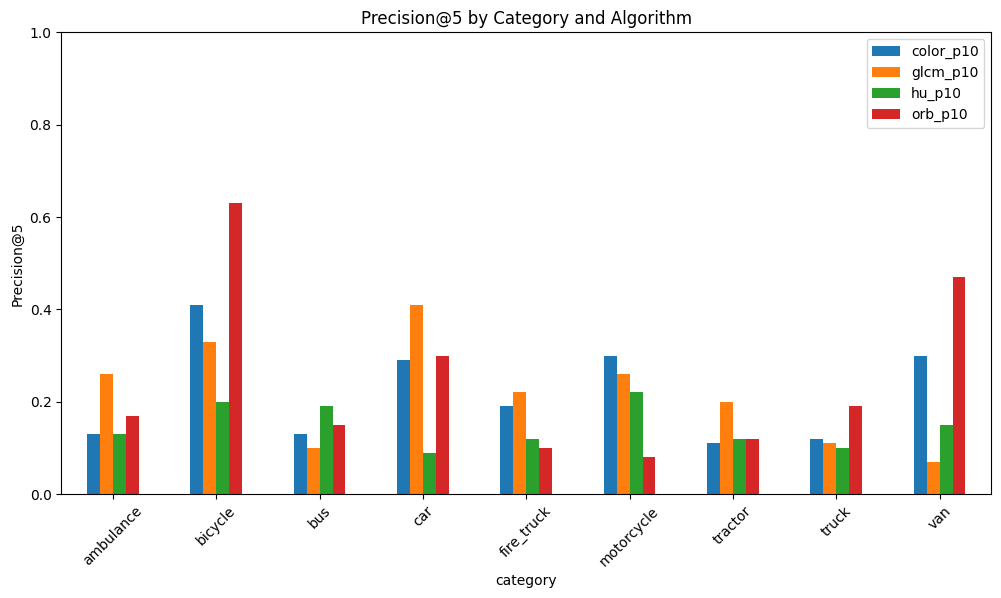

In [25]:
category_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Precision@5 by Category and Algorithm")
plt.ylabel("Precision@5")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

## Best Algorithm Selection

In [26]:
best_p5 = summary.loc[summary["Average Precision@5"].idxmax()]
best_p10 = summary.loc[summary["Average Precision@10"].idxmax()]

print("Best algorithm based on Precision@5:")
print(best_p5)

print("\nBest algorithm based on Precision@10:")
print(best_p10)

Best algorithm based on Precision@5:
Algorithm                    ORB
Average Precision@5     0.266667
Average Precision@10    0.245556
Name: 3, dtype: object

Best algorithm based on Precision@10:
Algorithm                    ORB
Average Precision@5     0.266667
Average Precision@10    0.245556
Name: 3, dtype: object


In [27]:
df_results.to_csv("evaluation_results.csv", index=False)
summary.to_csv("evaluation_summary.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


## Summary

This notebook compares four CBIR methods using multiple query images.

The evaluation shows that each algorithm has different strengths:
- Color Histogram performs better on color-rich categories
- GLCM performs better on texture-rich categories
- Hu Moments performs better on shape-focused categories
- ORB performs better on images with local keypoint details

The best method can be identified based on the average Precision@5 and Precision@10 scores.